In [1]:
import sys
!"{sys.executable}" -m pip install mysql-connector-python sqlalchemy pandas numpy matplotlib

   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
    --------------------------------------- 0.3/16.5 MB ? eta -:--:--
   - -------------------------------------- 0.5/16.5 MB 1.5 MB/s eta 0:00:11
   -- ------------------------------------- 1.0/16.5 MB 1.5 MB/s eta 0:00:11
   --- ------------------------------------ 1.3/16.5 MB 1.4 MB/s eta 0:00:11
   --- ------------------------------------ 1.3/16.5 MB 1.4 MB/s eta 0:00:11
   --- ------------------------------------ 1.6/16.5 MB 1.3 MB/s eta 0:00:12
   ----- ---------------------------------- 2.1/16.5 MB 1.3 MB/s eta 0:00:11
   ----- ---------------------------------- 2.4/16.5 MB 1.4 MB/s eta 0:00:11
   ------ --------------------------------- 2.9/16.5 MB 1.5 MB/s eta 0:00:10
   -------- ------------------------------- 3.7/16.5 MB 1.7 MB/s eta 0:00:08
   ---------- ----------------------------- 4.2/16.5 MB 1.8 MB/s eta 0:00:07
   ----------- ---------------------------- 4.7/16.5 MB 1.9 MB/s eta 0:00:07
   ----------

Connect to database

In [2]:
from sqlalchemy import create_engine
import pandas as pd

username = "root"
password = "root123"
host = "localhost"
database = "kyc_project"

engine = create_engine(
    f"mysql+mysqlconnector://{username}:{password}@{host}/{database}"
)

print("Connected")

Connected


Generate customers (1000)

In [3]:
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

n_customers = 1000

customers = pd.DataFrame({
    "age": np.random.randint(18,70,n_customers),
    "occupation": np.random.choice(
        ["salaried","business","student","self-employed","unemployed"],
        n_customers
    ),
    "income": np.random.randint(10000,100000,n_customers),
    "country": np.random.choice(
        ["india","uae","usa","uk"],
        n_customers
    ),
    "onboarding_date":[
        datetime.today() - timedelta(days=np.random.randint(0,2000))
        for _ in range(n_customers)
    ]
})

customers.to_sql("customers",engine,if_exists="append",index=False)

print("customers inserted")

customers inserted


Generate transactions (20000)

In [4]:
customers_df = pd.read_sql(
    "SELECT customer_id FROM customers",engine
)

ids = customers_df["customer_id"].values

n_txns = 20000

transactions = pd.DataFrame({
    "customer_id": np.random.choice(ids,n_txns),
    "amount": np.random.randint(500,100000,n_txns),
    "txn_type": np.random.choice(
        ["online","atm","transfer","pos"],n_txns
    ),
    "country": np.random.choice(
        ["india","uae","usa","uk"],n_txns
    ),
    "txn_date":[
        datetime.today() - timedelta(days=np.random.randint(0,365))
        for _ in range(n_txns)
    ]
})

transactions.to_sql(
    "transactions",engine,
    if_exists="append",
    index=False
)

print("transactions inserted")

transactions inserted


Create SQL View (feature layer)

In [6]:
from sqlalchemy import text

query = """
CREATE OR REPLACE VIEW customer_risk_features AS
SELECT 
    c.customer_id,
    c.income,
    c.country AS customer_country,
    COUNT(t.txn_id) AS total_txns,
    COALESCE(AVG(t.amount),0) AS avg_amount,
    COALESCE(SUM(
        CASE 
            WHEN t.country != c.country THEN 1
            ELSE 0
        END
    ),0) AS foreign_txns
FROM customers c
LEFT JOIN transactions t
ON c.customer_id = t.customer_id
GROUP BY c.customer_id,c.income,c.country;
"""

with engine.connect() as conn:
    conn.execute(text(query))
    conn.commit()

print("view created")

view created


Load features

In [7]:
customer_features = pd.read_sql(
    "SELECT * FROM customer_risk_features",
    engine
)

Risk scoring

In [8]:
def score(row):

    s = 0

    if row["avg_amount"] > 80000:
        s += 3
    elif row["avg_amount"] > 50000:
        s += 2

    if row["foreign_txns"] > 15:
        s += 3
    elif row["foreign_txns"] > 5:
        s += 2

    if row["total_txns"] > 60:
        s += 2
    elif row["total_txns"] > 30:
        s += 1

    if row["avg_amount"] > row["income"]:
        s += 2

    return s


customer_features["risk_score"] = \
    customer_features.apply(score,axis=1)

Risk label

In [9]:
def label(x):

    if x >= 7:
        return "High"
    elif x >= 3:
        return "Medium"
    else:
        return "Low"


customer_features["risk_level"] = \
    customer_features["risk_score"].apply(label)

Distribution

In [10]:
customer_features["risk_level"].value_counts()

risk_level
Medium    721
Low       167
High      112
Name: count, dtype: int64

Charts

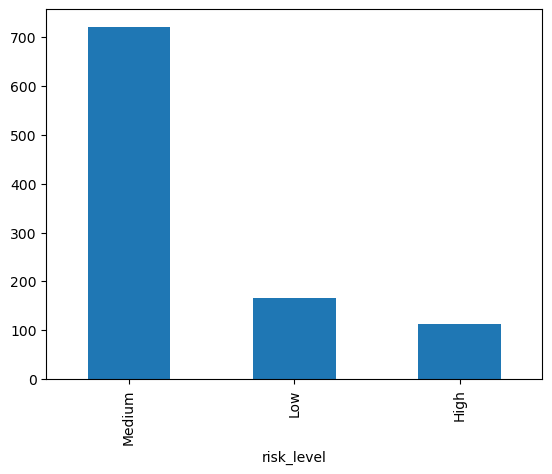

In [11]:
import matplotlib.pyplot as plt

customer_features["risk_level"]\
.value_counts().plot(kind="bar")

plt.show()